#Task 4: Custom Gradient Descent Optimizers with Momentum,RMSprop, and Ada
#Objective:
 Master adaptive learning rate mechanics and temporal update optimization
algorithms by implementing high-performance weight updates from scratch.
#Required Tech Stack:
PyTorch (using only tensor mathematics, no torch.optim), NumPy.
#Task Description:
 Students will design a training harness utilizing PyTorch tensors. They
must write optimizer update rules from scratch, calculating exponential moving averages of
first and second raw moments, applying bias corrections, and tracking loss convergence
rates on non-linear datasets.

Task4_Custom_Optimizers.ipynb

Cell 1 : Import Libraries
Cell 2 : Create Dataset
Cell 3 : Build Neural Network
Cell 4 : Loss Function
Cell 5 : SGD Optimizer
Cell 6 : Momentum Optimizer
Cell 7 : RMSprop Optimizer
Cell 8 : Adam Optimizer
Cell 9 : Training Function
Cell 10 : Train with SGD
Cell 11 : Train with Momentum
Cell 12 : Train with RMSprop
Cell 13 : Train with Adam
Cell 14 : Compare Loss Curves
Cell 15 : Compare Accuracy

Import Libraries

In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)

Create Dataset

In [2]:
X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Build Neural Network

In [3]:
class MLP(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = torch.nn.Linear(2,32)
        self.fc2 = torch.nn.Linear(32,16)
        self.fc3 = torch.nn.Linear(16,2)

    def forward(self,x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

Loss Function

In [4]:
criterion = torch.nn.CrossEntropyLoss()

SGD Optimizer

In [5]:
def sgd_update(params, lr):

    with torch.no_grad():

        for p in params:

            p -= lr * p.grad

Momentum Optimizer

In [6]:
velocity = {}

def momentum_update(params, lr, beta=0.9):

    with torch.no_grad():

        for i, p in enumerate(params):

            if i not in velocity:
                velocity[i] = torch.zeros_like(p)

            velocity[i] = beta * velocity[i] + p.grad

            p -= lr * velocity[i]

RMSprop Optimizer

In [7]:
cache = {}

def rmsprop_update(params, lr, beta=0.9, eps=1e-8):

    with torch.no_grad():

        for i, p in enumerate(params):

            if i not in cache:
                cache[i] = torch.zeros_like(p)

            cache[i] = beta * cache[i] + (1 - beta) * p.grad**2

            p -= lr * p.grad / (torch.sqrt(cache[i]) + eps)

Adam Optimizer

In [8]:
m = {}
v = {}

def adam_update(params, lr, epoch, beta1=0.9, beta2=0.999, eps=1e-8):

    with torch.no_grad():

        for i, p in enumerate(params):

            if i not in m:

                m[i] = torch.zeros_like(p)
                v[i] = torch.zeros_like(p)

            m[i] = beta1 * m[i] + (1 - beta1) * p.grad
            v[i] = beta2 * v[i] + (1 - beta2) * (p.grad**2)

            m_hat = m[i] / (1 - beta1**epoch)
            v_hat = v[i] / (1 - beta2**epoch)

            p -= lr * m_hat / (torch.sqrt(v_hat) + eps)

Training Function

In [9]:
def train(model, optimizer_name):

    losses = []

    for epoch in range(1,201):

        output = model(X_train)

        loss = criterion(output, y_train)

        loss.backward()

        if optimizer_name == "SGD":
            sgd_update(model.parameters(),0.01)

        elif optimizer_name == "Momentum":
            momentum_update(model.parameters(),0.01)

        elif optimizer_name == "RMSprop":
            rmsprop_update(model.parameters(),0.001)

        elif optimizer_name == "Adam":
            adam_update(model.parameters(),0.001,epoch)

        losses.append(loss.item())

        with torch.no_grad():
            for p in model.parameters():
                p.grad.zero_()

    return losses

Train with SGD

In [10]:
sgd_model = MLP()
sgd_loss = train(sgd_model, "SGD")

Train with Momentum

In [11]:
velocity.clear()

momentum_model = MLP()
momentum_loss = train(momentum_model, "Momentum")

Train with RMSprop

In [12]:
cache.clear()

rms_model = MLP()
rms_loss = train(rms_model, "RMSprop")

 Train with Adam

In [13]:
m.clear()
v.clear()

adam_model = MLP()
adam_loss = train(adam_model, "Adam")

 Compare Loss Curves

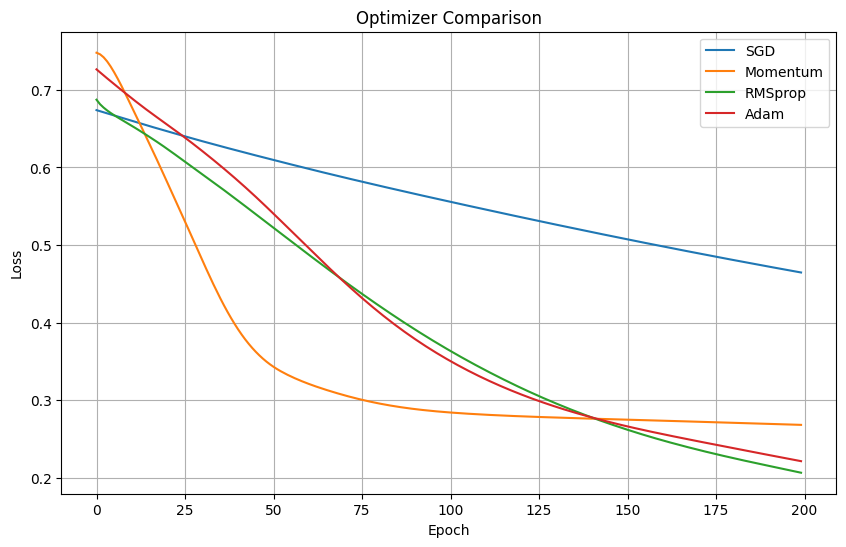

In [14]:
plt.figure(figsize=(10,6))

plt.plot(sgd_loss, label="SGD")
plt.plot(momentum_loss, label="Momentum")
plt.plot(rms_loss, label="RMSprop")
plt.plot(adam_loss, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid()

plt.show()

Compare Accuracy

In [15]:
def accuracy(model):

    with torch.no_grad():

        pred = torch.argmax(model(X_test), dim=1)

        acc = (pred == y_test).float().mean()

    return acc.item() * 100

print("SGD      :", accuracy(sgd_model))
print("Momentum :", accuracy(momentum_model))
print("RMSprop  :", accuracy(rms_model))
print("Adam     :", accuracy(adam_model))

SGD      : 79.50000166893005
Momentum : 87.99999952316284
RMSprop  : 92.00000166893005
Adam     : 91.00000262260437
